# Tarea 3 Algoritmos de Aprendizaje Supervisado #
## Regresión Lineal – Vehicle dataset ##
### Jaime Daniel Cerón Rosales ###
### UNAD - 2025 ###

Objetivo: Predecir el precio del automóvil en función de sus atributos.


    1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.
    2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario.
    3. Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características.
    4. Dividir el dataset en Train y Test para evaluar correctamente el modelo.
    5. Entrenar el modelo configurando los diferentes hiperparámetros.
    6. Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc.
    7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo.
    8. Interpretar, analizar y documentar los resultados obtenido.

### 1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias. ###

In [55]:
# Importaremos librerias necesarias

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_error
from math import sqrt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from warnings import filterwarnings
filterwarnings("ignore")

# Cargar el dataset
df = pd.read_csv('/content/car data.csv')

Veremos el tamaño de los datos usando shape:

In [2]:
df.shape

(301, 9)

Miramos los primeros datos del conjunto usando head():

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Con df.info miramos información general sobre el DataFrame. Esta información incluye el número de filas y columnas, el tipo de datos, el uso de memoria, y más.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Generamos un resumen estadístico de las columnas del DataFrame. Este resumen incluye información sobre la tendencia central, la dispersión y la forma de la distribución de los datos.

In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


Con df.isna().sum() contamos valores nulos

In [6]:
# Revisar valores nulos
#Missing Values
df.isna().sum() # identify Missing Value

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [7]:
df.duplicated().sum()

np.int64(2)

**Variables categóricas**

In [8]:
# Verificar valores únicos en variables categóricas
print(df['Fuel_Type'].value_counts())
print(df['Seller_Type'].value_counts())
print(df['Transmission'].value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


**Variables numéricas**

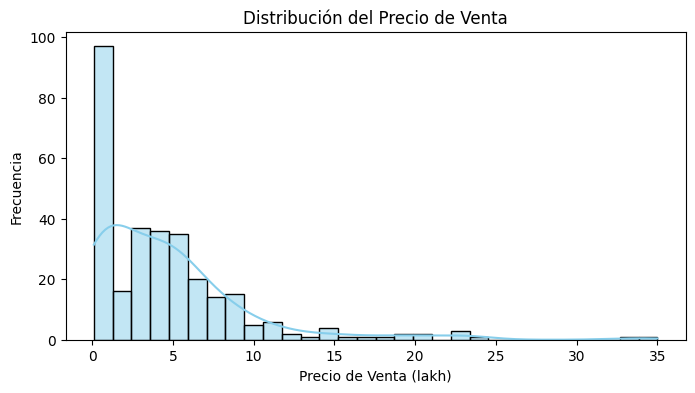

In [9]:
# Distribución del precio de venta
plt.figure(figsize=(8, 4))
sns.histplot(df['Selling_Price'], kde=True, bins=30, color='skyblue')
plt.title('Distribución del Precio de Venta')
plt.xlabel('Precio de Venta (lakh)')
plt.ylabel('Frecuencia')
plt.show()

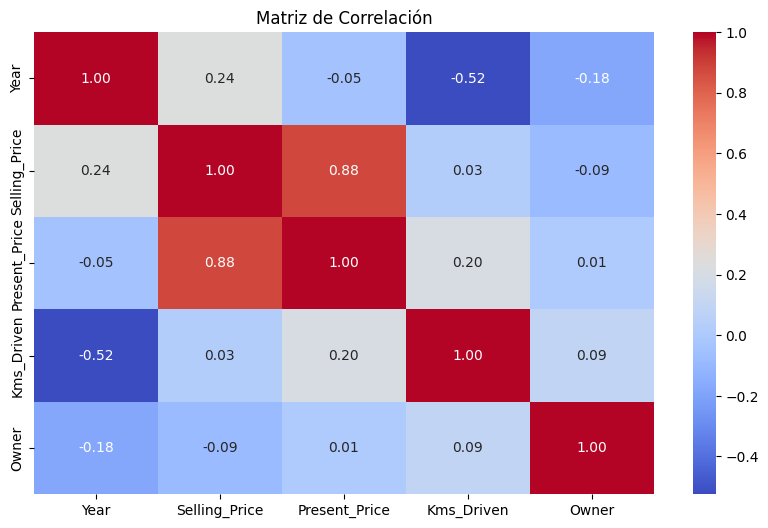

                   Year  Selling_Price  Present_Price  Kms_Driven     Owner
Year           1.000000       0.236141      -0.047584   -0.524342 -0.182104
Selling_Price  0.236141       1.000000       0.878983    0.029187 -0.088344
Present_Price -0.047584       0.878983       1.000000    0.203647  0.008057
Kms_Driven    -0.524342       0.029187       0.203647    1.000000  0.089216
Owner         -0.182104      -0.088344       0.008057    0.089216  1.000000


In [10]:
# Correlación entre variables numéricas
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=np.number) # Select only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()
print(numeric_df.corr())

La variable `Selling_Price `(precio de venta) tiene una alta correlación positiva con Present_Price (precio original del auto), con un coeficiente de 0.88, lo cual tiene sentido ya que los autos más caros originalmente tienden a venderse a precios más altos.

`Year `(año del vehículo) tiene una correlación moderadamente positiva con el precio de venta (0.23) y una correlación negativa con los kilómetros recorridos (Kms_Driven), indicando que los autos más nuevos tienden a estar menos usados.

`Kms_Driven` y `Owner` tienen correlaciones muy bajas o negativas con el precio de venta, lo que sugiere que tienen una influencia más débil en el precio o podrían necesitar transformación para capturar mejor su efecto.

La variable `Owner` (número de dueños previos) tiene una ligera correlación negativa con el precio de venta, lo cual también es intuitivo: autos con más dueños previos suelen venderse más baratos.

## 2. Preprocesamiento de datos

A partir de la exploración inicial de los datos se puede continuar con el preprocesamiento de los datos para esto se eliminará las columnas innecesarias en este caso solo el nombre del auto ya que no aporta un valor predictivo.
Adicionalmente se crea una columna nueva llamada Age donde se indica la edad del auto, esto porque los autos más nuevos son del 2019, entonces todos los autos tendrán entre 6 y más años de antigüedad, lo cual podría distorsionar la relación real entre edad y precio al exagerarla

In [11]:

for i in range(len(df)):
    df['Age']= df['Year'].max()+1-df['Year']
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,3
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,4
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,10
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,2


In [23]:
data = df.copy()
data.drop(['Car_Name', 'Year'], axis=1, inplace=True)
data

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,5
...,...,...,...,...,...,...,...,...
296,9.50,11.60,33988,Diesel,Dealer,Manual,0,3
297,4.00,5.90,60000,Petrol,Dealer,Manual,0,4
298,3.35,11.00,87934,Petrol,Dealer,Manual,0,10
299,11.50,12.50,9000,Diesel,Dealer,Manual,0,2


Crearemos una nueva columna llamada Edad del vehiculo con el fin de saber cuantos años tiene un vehiculo.

In [24]:

# Verificando la columna age
print(data[['Age']].head())

   Age
0    5
1    6
2    2
3    8
4    5


Ahora se va a transformar las variables categóricas en variables numéricas mediante codificación One-Hot Encoding

In [25]:
data = pd.get_dummies(data, drop_first=True)


In [26]:
data.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,5,False,True,False,True
1,4.75,9.54,43000,0,6,True,False,False,True
2,7.25,9.85,6900,0,2,False,True,False,True
3,2.85,4.15,5200,0,8,False,True,False,True
4,4.60,6.87,42450,0,5,True,False,False,True


Se escala las variables numéricas

In [27]:
scaler = StandardScaler()
numerical_features = ['Present_Price', 'Kms_Driven', 'Owner', 'Age']

data[numerical_features] = scaler.fit_transform(data[numerical_features])

# Mostramos el dataframe procesado
print(data.head())

   Selling_Price  Present_Price  Kms_Driven     Owner       Age  \
0           3.35      -0.236215   -0.256224 -0.174501 -0.128897   
1           4.75       0.221505    0.155911 -0.174501  0.217514   
2           7.25       0.257427   -0.773969 -0.174501 -1.168129   
3           2.85      -0.403079   -0.817758 -0.174501  0.910335   
4           4.60      -0.087890    0.141743 -0.174501 -0.128897   

   Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Individual  \
0             False              True                   False   
1              True             False                   False   
2             False              True                   False   
3             False              True                   False   
4              True             False                   False   

   Transmission_Manual  
0                 True  
1                 True  
2                 True  
3                 True  
4                 True  


**División de los datos en test y train**
 Se hace el split con 20% para test y 80% train  con una semilla random de 15

In [28]:
X = data.drop('Selling_Price', axis=1)
y = data['Selling_Price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##3. Selección de características
Se va a utilizar selectKbest para obtener las mejores características que influyen en el modelo

In [29]:
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

SelectKBest(k='all', score_func=<function f_regression at 0x7e74fd06ab60>)

In [30]:
# resultados
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print(feature_scores)

                  Feature       Score
0           Present_Price  901.950884
4        Fuel_Type_Diesel  109.601856
5        Fuel_Type_Petrol  101.080486
6  Seller_Type_Individual   99.501609
7     Transmission_Manual   38.697364
3                     Age   12.054040
2                   Owner    1.783704
1              Kms_Driven    0.268703


Se puede observar que `Present_Price `La relación con el precio actual del automóvil es bastante alta.
`Fuel_Type_Diesel` y `Fuel_Type_Petrol`la codificación de tipo de combustible muestra que estos factores son importantes, ya que los automóviles diésel o de gasolina tienden a tener diferentes precios.`Seller_Type_Individual` indica si el vendedor es un individuo o una empresa, lo cual afecta el precio de venta.

`Transmission_Manual` el tipo de transmisión también tiene un impacto significativo en el precio.Year y Age: Estas variables relacionadas con la antigüedad del auto tienen una correlación moderada, ya que la edad influye en el valor de reventa de un automóvil.

`Owner`: El número de propietarios anteriores tiene una influencia pequeña pero relevante.

`Kms_Driven`: El kilometraje también es importante, aunque con una influencia menor.

A continuación, se generan histogramas para cada columna del DataFrame con el fin de analizar la distribución de sus valores. Esta visualización permite identificar patrones, posibles valores atípicos y el comportamiento general de cada variable en el conjunto de datos.

## 4. Division train y test
Esto fue realizado en el preprocesamiento

##5. Entramiento del modelo con ajuste de hiperparámetros
Para el modelo de Regresión Lineal se utiliza un ajuste de hiperparámetros. En el caso de la regresión lineal, los hiperparámetros más relevantes que se podría ajustar son aquellos relacionados con la regularización, como Ridge o Lasso, que pueden ser útiles para manejar la multicolinealidad y evitar el sobreajuste.

Adicionalmente se va a seguir con los pasos de entrenamiento y ajuste de los hiperparámetros usando GridSearchCV con validación cruzada (k-fold).

In [33]:
## creación del modelo de Regresión Lineal
linear_model = LinearRegression()

In [34]:

linear_model.fit(X_train, y_train)

LinearRegression()

In [35]:
y_pred_linear = linear_model.predict(X_test)

In [44]:
## Evaluando el modelo antes de aplicar las regularizaciones
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Resultados del modelo de Regresión Lineal:")
print(f"Error absoluto medio (MAE): {mae_linear}")
print(f"Error cuadrático medio (MSE): {mse_linear}")
print(f"Raíz del error cuadrático medio (RMSE): {rmse_linear}")
print(f"R2: {r2_linear}")

Resultados del modelo de Regresión Lineal:
Error absoluto medio (MAE): 1.2162256821297064
Error cuadrático medio (MSE): 3.4788039706379035
Raíz del error cuadrático medio (RMSE): 1.8651552135513825
R2: 0.8489813024899066


**Regularizacion**
Ridge y Lasso se entrenan utilizando la búsqueda de hiperparámetros con alpha variando entre valores logarítmicos. El modelo con el mejor valor de alpha se selecciona y evalúa en los datos de prueba. Se comparan las métricas de desempeño de Ridge, Lasso y Regresión Lineal para ver si la regularización mejora el modelo.

In [45]:
param_grid = {'alpha': np.logspace(-6, 6, 13)}  # alpha variando en una escala logarítmica

#  modelo Ridge y Lasso
ridge = Ridge()
lasso = Lasso()

#objeto GridSearchCV para Ridge y Lasso
grid_ridge = GridSearchCV(estimator=ridge, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)
grid_lasso = GridSearchCV(estimator=lasso, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)

In [47]:
# Ajustando los modelos a los datos de entrenamiento
grid_ridge.fit(X_train, y_train)
grid_lasso.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
       1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06])},
             scoring='neg_mean_squared_error')

In [48]:
# mejores parámetros y el desempeño del modelo
print("Mejores parámetros para Ridge:", grid_ridge.best_params_)
print("Mejores parámetros para Lasso:", grid_lasso.best_params_)

Mejores parámetros para Ridge: {'alpha': np.float64(10.0)}
Mejores parámetros para Lasso: {'alpha': np.float64(0.0001)}


Se evalua las metricas para cada una de las regularizaciones, ya se observó que Lasso hace ajuste muy pequeños a las variables casi cerca a la regresión lineal

In [52]:
#  los modelos con los mejores parámetros
ridge_best = grid_ridge.best_estimator_
lasso_best = grid_lasso.best_estimator_
# Predicciones y métricas de desempeño para Ridge
y_pred_ridge = ridge_best.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Predicciones y métricas de desempeño para Lasso
y_pred_lasso = lasso_best.predict(X_test)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

# Resultados para Ridge y Lasso
print("\nResultados del modelo Ridge:")
print(f"MAE: {mae_ridge}, MSE: {mse_ridge}, RMSE: {rmse_ridge}, R2: {r2_ridge}")

print("\nResultados del modelo Lasso:")
print(f"MAE: {mae_lasso}, MSE: {mse_lasso}, RMSE: {rmse_lasso}, R2: {r2_lasso}")


Resultados del modelo Ridge:
MAE: 1.2228263336779777, MSE: 3.5345004359033467, RMSE: 1.8800267114866605, R2: 0.8465634578193542

Resultados del modelo Lasso:
MAE: 1.216158776382983, MSE: 3.4784665983178202, RMSE: 1.8650647705422512, R2: 0.8489959481925058


En este caso, el modelo de regresión lineal sin regularización podría ser la mejor opción dado su desempeño y la simplicidad del modelo. R2: Los tres modelos tienen un valor R² muy similar (alrededor de 0.849), lo que indica que todos explican una cantidad comparable de la variabilidad en los precios de los automóviles.

Métricas de error: Las métricas de MAE, MSE y RMSE también son muy cercanas entre sí, con el modelo Lasso teniendo una ligera ventaja en MAE y MSE. Sin embargo, la diferencia es mínima.

## 6. Evaluación del modelo

El modelo con el cual se evaluará será el modelo lineal sin regularizaciones, asi mismo se hace la evaluación de los residuos que son la diferencia entre los valores reales y las predicciones del modelo. Es importante observar los residuos para asegurarse de que el modelo esté ajustado correctamente.



In [57]:
y_pred = linear_model.predict(X_test)

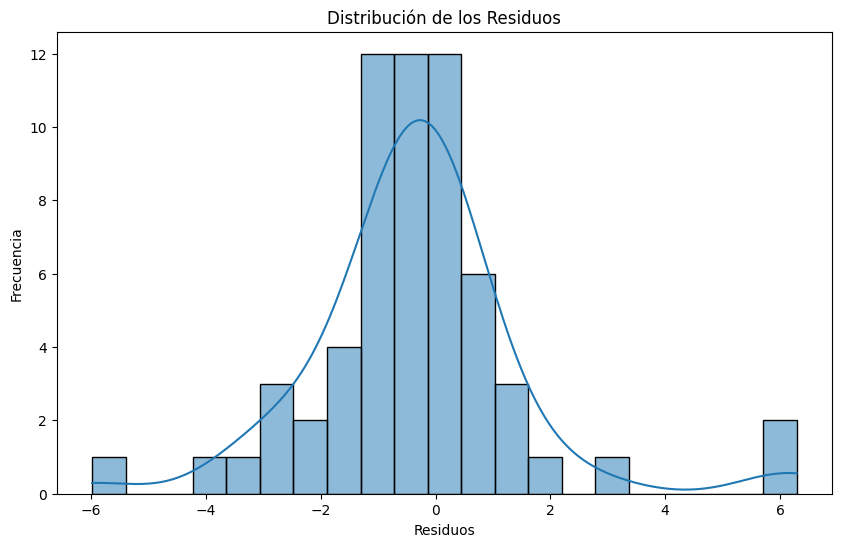

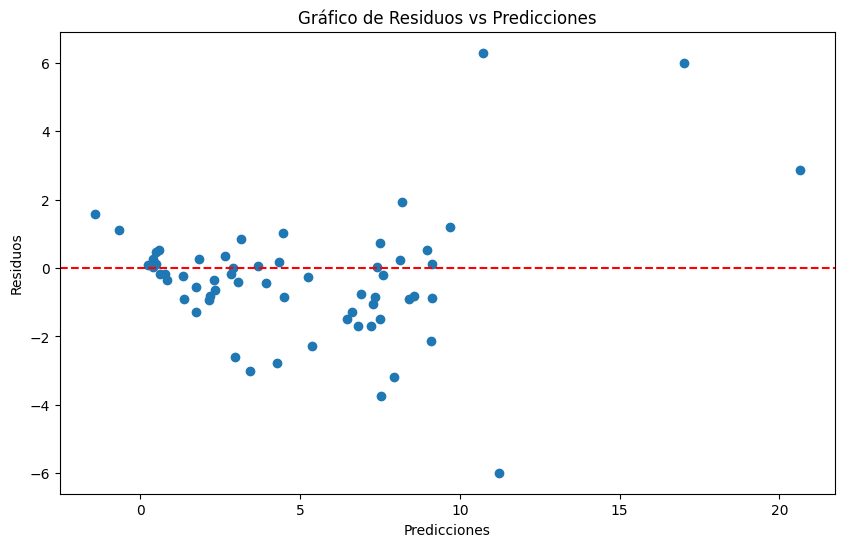

In [59]:
# Residuos
residuos = y_test - y_pred

# Visualización de los residuos
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de los residuos
plt.figure(figsize=(10, 6))
sns.histplot(residuos, kde=True)
plt.title("Distribución de los Residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

# Gráfico de dispersión de los residuos
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title("Gráfico de Residuos vs Predicciones")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.show()

## 7. Visualización de los resultados
Otra manera de evaluar el desempeño del modelo es graficar las predicciones frente a los valores reales. Esto te permitirá ver cómo se ajustan las predicciones a los datos.

**Gráfico de predicciones vs valores reales**


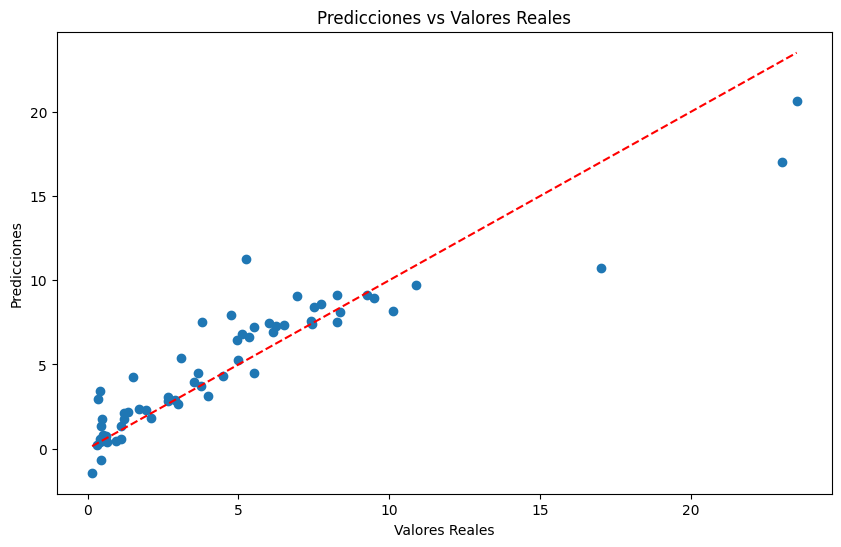

In [60]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title("Predicciones vs Valores Reales")
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.show()

**Gráfico de coeficientes del modelo**

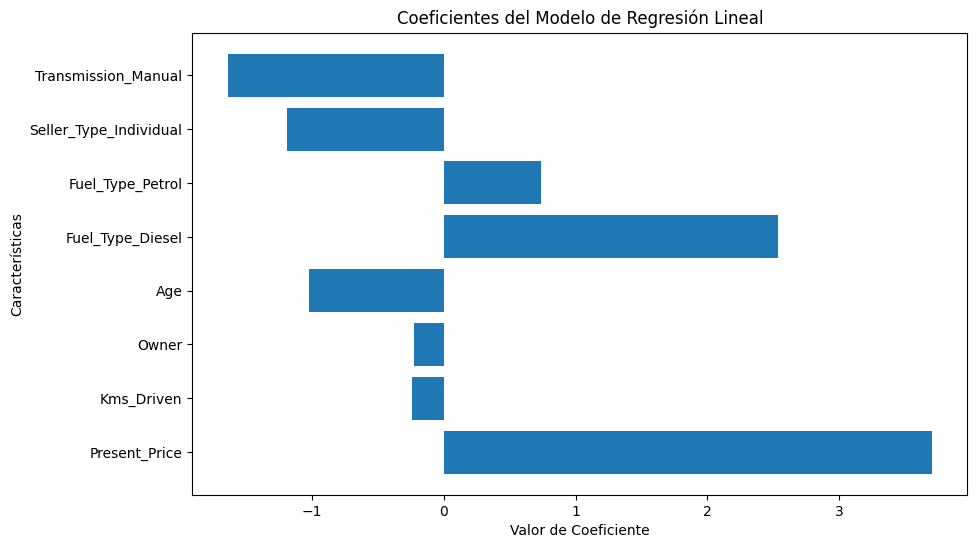

[ 3.70347643 -0.23903854 -0.22368302 -1.02133499  2.53327258  0.73846423
 -1.19059291 -1.63902155] Index(['Present_Price', 'Kms_Driven', 'Owner', 'Age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual'],
      dtype='object')


In [64]:
# Coeficientes del modelo de regresión lineal
coeficientes = linear_model.coef_
features = X_train.columns

# Gráfico de coeficientes
plt.figure(figsize=(10, 6))
plt.barh(features, coeficientes)
plt.title("Coeficientes del Modelo de Regresión Lineal")
plt.xlabel("Valor de Coeficiente")
plt.ylabel("Características")
plt.show()

print(coeficientes, features)

## 8. Analisis de resultados

Un coeficiente positivo de 3.70 indica que a medida que el precio actual del automóvil aumenta, también lo hace el precio de venta. Esto es lógico, ya que un precio más alto en el mercado generalmente refleja un automóvil más valioso.Por otra parte un coeficiente negativo de -0.24 indica que, a medida que un automóvil ha recorrido más kilómetros, su precio de venta tiende a reducirse. Los automóviles con más kilómetros generalmente tienen un valor de reventa más bajo.

Para el número de propietarios, un coeficiente negativo de -0.22 indica que si el automóvil ha tenido más propietarios, su precio de venta puede ser más bajo. Los automóviles con más propietarios pueden percibirse como menos deseables o tener un historial de mantenimiento menos claro.

Edad del automóvil,un coeficiente negativo de -1.02 sugiere que a medida que un automóvil envejece, su precio de venta tiende a reducirse. Este comportamiento es común, ya que los autos pierden valor con el tiempo debido al desgaste y la obsolescencia.

el Tipo de combustible - Diésel Un coeficiente positivo de 2.53 indica que los automóviles con motores diésel tienden a tener precios de venta más altos. Esto podría ser debido a la percepción de que los vehículos diésel son más eficientes en términos de consumo de combustible o tienen una mayor durabilidad. Como para Tipo de combustible - Gasolina, Similar al diésel, un coeficiente positivo de 0.73 indica que los automóviles con motores a gasolina también tienen precios relativamente altos. Sin embargo, el coeficiente es más bajo que para los vehículos diésel. Un coeficiente negativo de -1.19 sugiere que los automóviles vendidos por individuos tienen un precio más bajo en comparación con los vendidos por concesionarios. Esto podría deberse a que los autos vendidos por individuos a menudo tienen menos garantías y menos transparencia en su historial.

Finalmente para la transmision manual Un coeficiente negativo de -1.64 indica que los automóviles con transmisión manual tienden a tener precios más bajos en comparación con los automóviles con transmisión automática. Esto podría estar relacionado con la preferencia del mercado por la comodidad de las transmisiones automáticas.